In [2]:
# Generic packages
import numpy as np 
import matplotlib.pyplot as plt
from os import listdir
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Style 
plt.style.use('seaborn-pastel')

### Initialization

In [3]:
def build_dataset(path):
    """
    build_dataset(path)

        Import dataset from path, normalize data and separate in train and test datasets.

        -path (str) :
            Path to the dataset files. 
    """
    TES = np.concatenate([np.fromfile(f"{path}{fileName}",dtype=np.uint16).reshape(-1,496) for fileName in listdir(path)])
    shape = np.shape(TES)
    minTES = np.min(TES)
    maxTES = np.max(TES)

    #X = (X - np.mean(X)) / (np.std(X))
    X = (TES - minTES) / (maxTES - minTES)

    X_train, X_test = train_test_split(X, test_size=0.001, random_state=0)

    print(f"Dataset contains :",
        f"\nSamples : {shape[0]}",
        f"\nLenght of samples : {shape[1]}",
        f"\nNumber of train samples : {len(X_train)}",
        f"\nNumber of test samples {len(X_test)}")
    
    return X_train , X_test

### Plot TES

Dataset contains : 
Samples : 52224 
Lenght of samples : 496 
Number of train samples : 52171 
Number of test samples 53


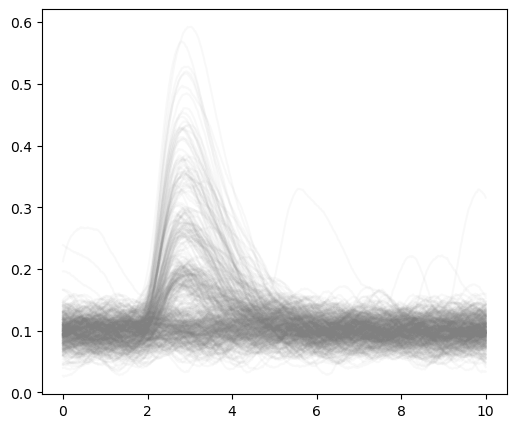

In [4]:
X, X_test = build_dataset("Datasets/Guillaume Thekkadath/")
signalSize = len(X_test[0])
time = np.linspace(0,10,signalSize)

plt.figure(figsize=(6,5))
plot = [plt.plot(time, X[i], color=[0.5,0.5,0.5],alpha=0.05) for i in range(signalSize)]

### Principal Component Analysis (PCA)

In [5]:
componentNB = 100   # Number of principal components
pca = PCA(n_components=componentNB, svd_solver="full")
X_pca = pca.fit_transform(X)

#### First `N` components

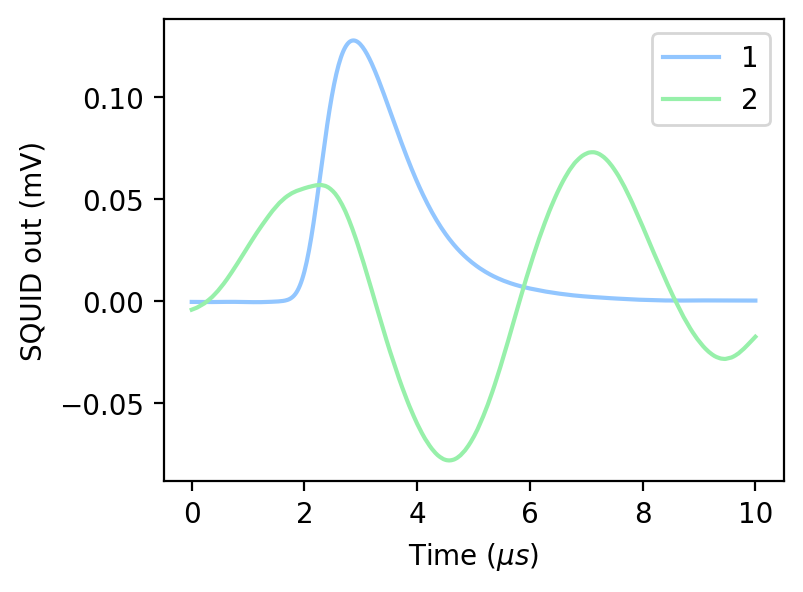

In [6]:
N = 2
plt.figure(figsize=(4,3),dpi=200)
plot = [plt.plot(time, pca.components_[i], label=f"{i+1}") for i in range(N)]
plt.ylabel(r"SQUID out (mV)")
plt.xlabel(r"Time ($\mu s$)")
plt.legend()

#### Variance $\sigma_j$ of the set of principal component

Text(0.5, 0, 'Principal Component j')

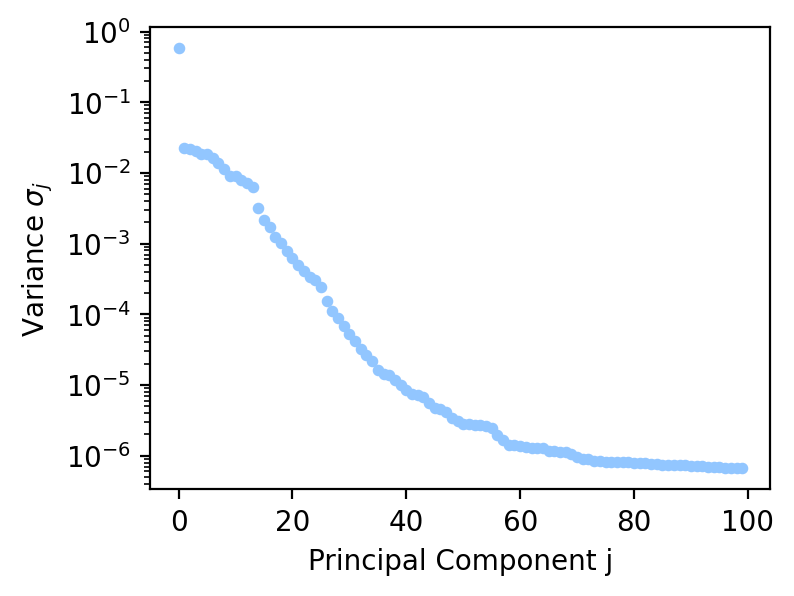

In [7]:
plt.figure(figsize=(4,3),dpi=200)
plt.scatter(range(componentNB), pca.explained_variance_, s=10)
plt.yscale("log")
plt.ylabel(r"Variance $\sigma_j$")
plt.xlabel(r"Principal Component j")

#### 2 Principal components

Text(0, 0.5, '$S_2$')

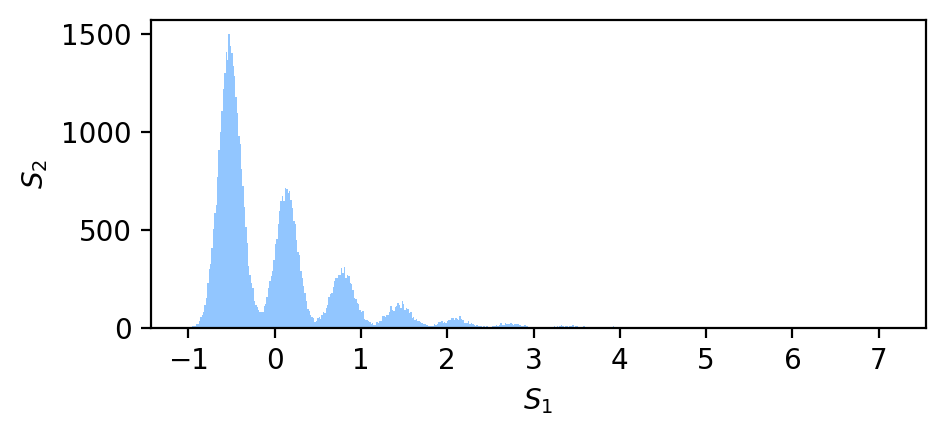

In [9]:
plt.figure(figsize=(5,2),dpi=200)
#plt.scatter(X_pca[:, 0], X_pca[:, 1],alpha=0.1,s=4)
plt.hist(X_pca[:, 0],bins=500)
plt.xlabel(r'$S_1$')
plt.ylabel(r'$S_2$')